# Dual-Agent Belief-Aware LLMs Evaluation Analysis
This notebook provides extensive visualizations of the `eval_results_dual_agent.csv` data.
It focuses on the dual-agent runs, comparing Reasoner/Matcher pairs, Metric Families (Binding vs End-to-End), and different contexts.


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)


def set_dynamic_ylim(ax=None, values=None, floor=0.0, pad_ratio=0.08):
    """Set a tight y-range from the values actually being plotted."""
    ax = ax or plt.gca()
    if values is None:
        values = [patch.get_height() for patch in ax.patches]
    values = [value for value in values if pd.notna(value) and value > 0]
    if not values:
        return

    y_min = min(values)
    y_max = max(values)
    span = y_max - y_min
    if span == 0:
        span = max(abs(y_max), 1.0) * 0.05

    lower = max(floor, y_min - span * pad_ratio)
    upper = y_max + span * pad_ratio
    ax.set_ylim(lower, upper)


## Data Loading and Transformation

In [62]:
# Load the data
df = pd.read_csv('eval_results_dual_agent.csv')

# Clean up legacy entries
df = df[df['Model'] != 'unknown']

# Keep the available runs in the current CSV.
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')

# We are primarily interested in 'Average_Accuracy' for these comparisons
df_acc = df[df['Summary_Metric'] == 'Average_Accuracy'].copy()

# Create a composite column for the Agent Pair
df_acc['Agent_Pair'] = df_acc['Reasoner_Model'] + " + " + df_acc['Matcher_Model']

# Melt the dataframe to make the context types a single categorical column
id_vars = ['Timestamp', 'Domain', 'Agent_Pair', 'Reasoner_Model', 'Matcher_Model', 'Temp', 'Prompt_Ver', 'Runs', 'Metric_Family']
value_vars = ['Dual_Agent_Store', 'Dual_Agent_Store_History']

df_melted = pd.melt(df_acc, id_vars=id_vars, value_vars=value_vars, 
                    var_name='Context_Type', value_name='Accuracy')

# Clean up Accuracy values - handle cases with typos
df_melted['Accuracy'] = df_melted['Accuracy'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df_melted['Accuracy'] = pd.to_numeric(df_melted['Accuracy'], errors='coerce')
df_melted = df_melted.dropna(subset=['Accuracy'])

df_melted.head()


,Timestamp,Domain,Agent_Pair,Reasoner_Model,Matcher_Model,Temp,Prompt_Ver,Runs,Metric_Family,Context_Type,Accuracy
0,2026-05-10 01:11:54,loan_absurd,llama3.2:1b + gemma3:1b,llama3.2:1b,gemma3:1b,0.0,v15,1,Binding,Dual_Agent_Store,0.7
1,2026-05-10 01:11:54,loan_absurd,llama3.2:1b + gemma3:1b,llama3.2:1b,gemma3:1b,0.0,v15,1,End_to_End,Dual_Agent_Store,0.8
2,2026-05-10 01:13:28,alien_clinic_absurd,llama3.2:1b + gemma3:1b,llama3.2:1b,gemma3:1b,0.0,v15,1,Binding,Dual_Agent_Store,0.9
3,2026-05-10 01:13:28,alien_clinic_absurd,llama3.2:1b + gemma3:1b,llama3.2:1b,gemma3:1b,0.0,v15,1,End_to_End,Dual_Agent_Store,1.0
4,2026-05-10 01:14:55,crime_scene_absurd,llama3.2:1b + gemma3:1b,llama3.2:1b,gemma3:1b,0.0,v15,1,Binding,Dual_Agent_Store,0.9


## 1. Metric Family: Binding vs End-to-End
Comparing how well models bind facts vs overall end-to-end correctness.

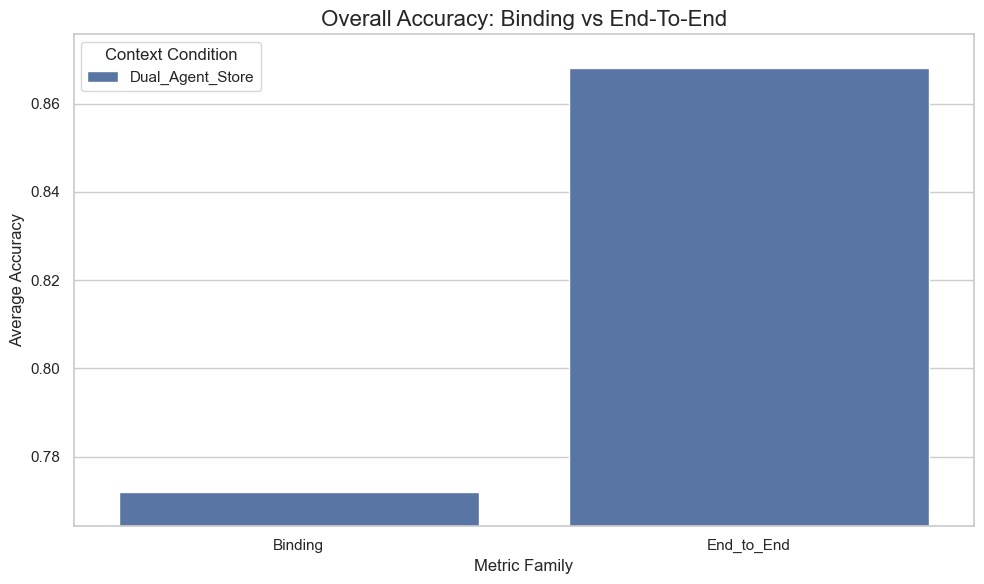

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric_Family', y='Accuracy', hue='Context_Type', errorbar=None)
plt.title('Overall Accuracy: Binding vs End-To-End', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Metric Family')
plt.legend(title='Context Condition')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## 2. Agent Pairing Comparisons
Which combinations of Reasoner and Matcher yield the best results?

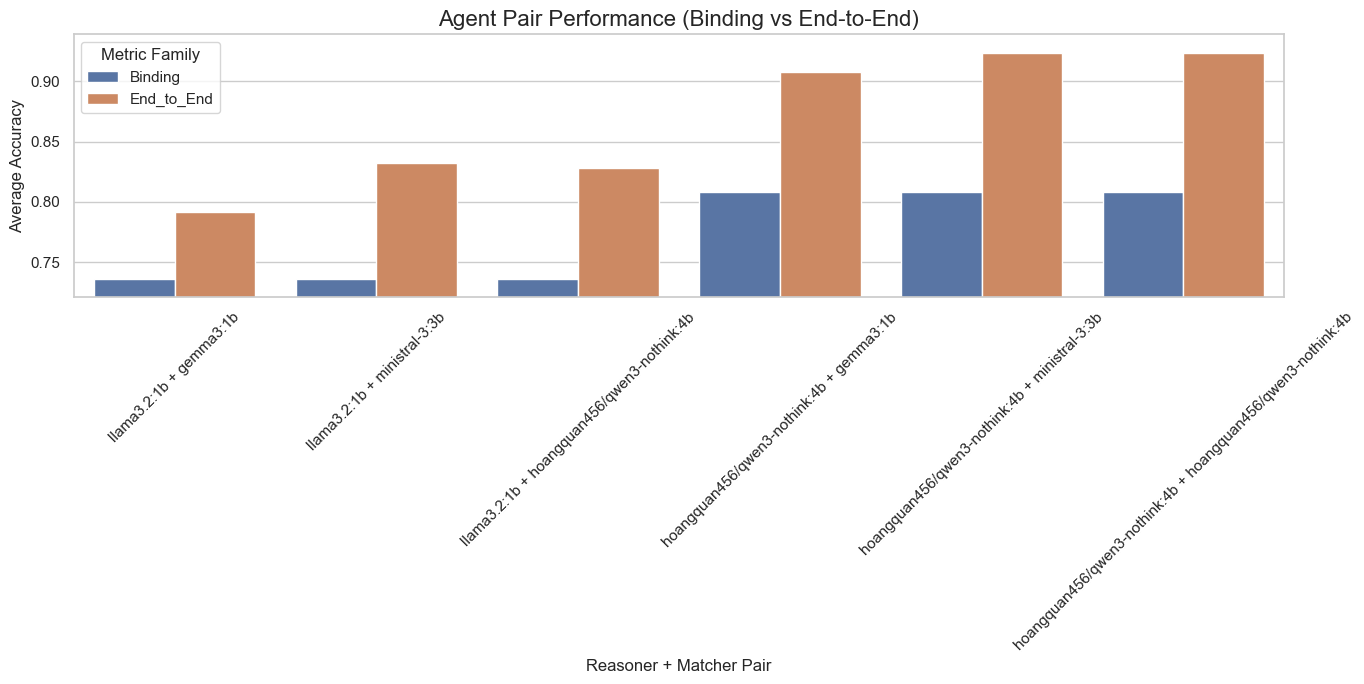

In [64]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Agent_Pair', y='Accuracy', hue='Metric_Family', errorbar=None)
plt.title('Agent Pair Performance (Binding vs End-to-End)', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Reasoner + Matcher Pair')
plt.xticks(rotation=45)
plt.legend(title='Metric Family')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


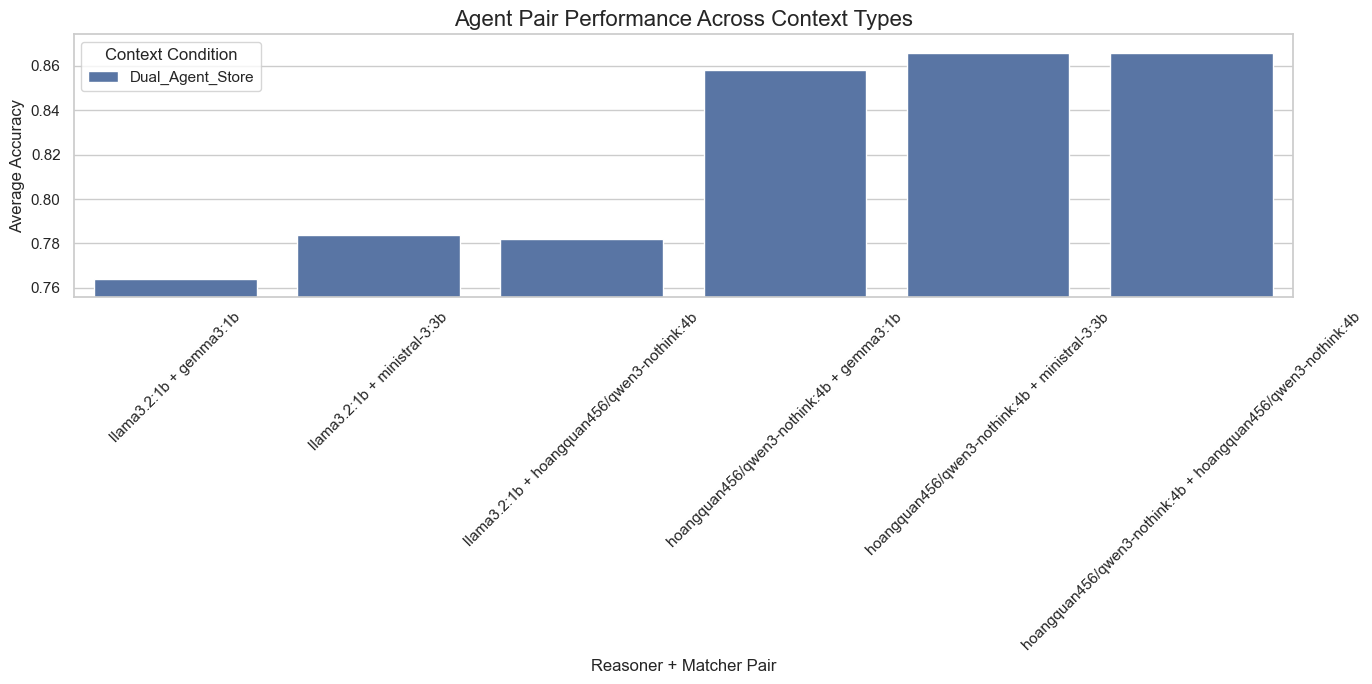

In [65]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Agent_Pair', y='Accuracy', hue='Context_Type', errorbar=None)
plt.title('Agent Pair Performance Across Context Types', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Reasoner + Matcher Pair')
plt.xticks(rotation=45)
plt.legend(title='Context Condition')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## 3. Domain and Scenario Feature Extraction
Splitting the Domain strings into Base Domains and Scenarios.

In [ ]:
# Extract Base Domain and Scenario Type
def extract_base_domain(domain):
    for base in ['loan', 'alien_clinic', 'crime_scene', 'thorncrester']:
        if domain.startswith(base):
            return base
    return 'other'

def extract_scenario(domain):
    for scenario in ['_belief_maintenance', '_negation', '_absurd_temporal', '_grounding', '_absurd', '_trace_selection']:
        if domain.endswith(scenario):
            return scenario.lstrip('_')
    return 'base'

df_melted['Base_Domain'] = df_melted['Domain'].apply(extract_base_domain)
df_melted['Scenario'] = df_melted['Domain'].apply(extract_scenario)

df_melted[['Domain', 'Base_Domain', 'Scenario']].head()


,Domain,Base_Domain,Scenario
0,loan_absurd,loan,base
1,loan_absurd,loan,base
2,alien_clinic_absurd,alien_clinic,base
3,alien_clinic_absurd,alien_clinic,base
4,crime_scene_absurd,crime_scene,base


## 4. Performance by Domain & Scenario (End-to-End only)

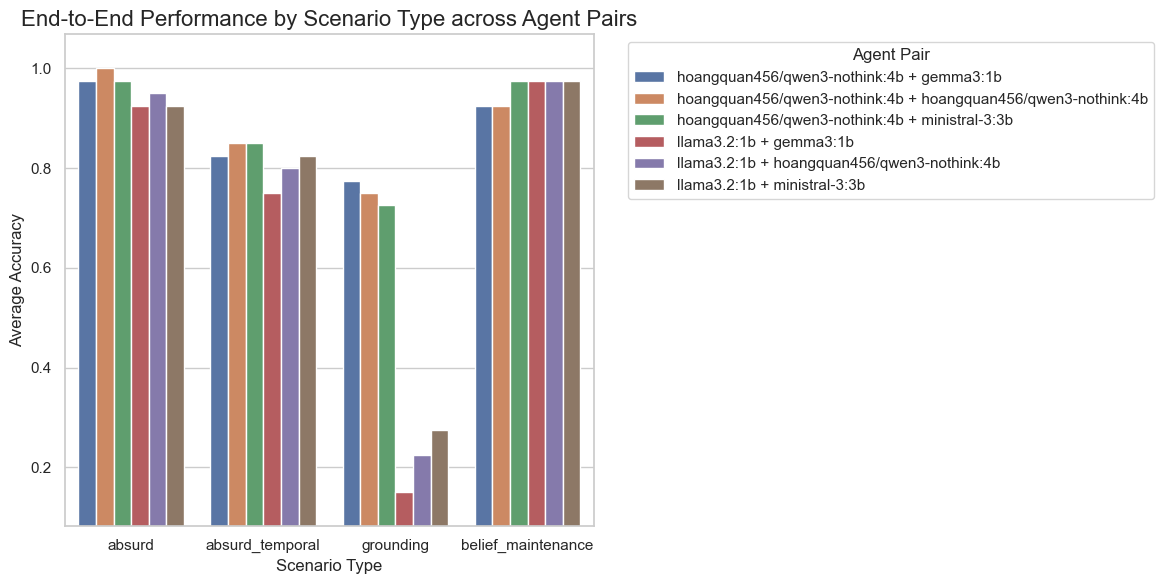

In [73]:
# Filter for End_to_End metrics for cleaner domain comparisons
def extract_base_domain(domain):
    for base in ['loan', 'alien_clinic', 'crime_scene', 'thorncrester']:
        if str(domain).startswith(base):
            return base
    return 'other'

def extract_scenario(domain):
    for scenario in ['_belief_maintenance', '_negation', '_absurd_temporal', '_grounding', '_absurd', '_trace_selection']:
        if str(domain).endswith(scenario):
            return scenario.lstrip('_')
    return 'base'

df_melted['Base_Domain'] = df_melted['Domain'].apply(extract_base_domain)
df_melted['Scenario'] = df_melted['Domain'].apply(extract_scenario)

df_e2e = df_melted[df_melted['Metric_Family'] == 'End_to_End'].copy()

scenario_order = ['absurd', 'absurd_temporal', 'grounding', 'belief_maintenance']
df_e2e = df_e2e[df_e2e['Scenario'].isin(scenario_order)].copy()
df_e2e['Scenario'] = pd.Categorical(df_e2e['Scenario'], categories=scenario_order, ordered=True)

df_plot = (
    df_e2e.groupby(['Scenario', 'Agent_Pair'], as_index=False)['Accuracy']
    .mean()
 )
all_pairs = sorted(df_plot['Agent_Pair'].unique())
scaffold = pd.MultiIndex.from_product([scenario_order, all_pairs], names=['Scenario', 'Agent_Pair']).to_frame(index=False)
df_plot = scaffold.merge(df_plot, on=['Scenario', 'Agent_Pair'], how='left')
df_plot['Accuracy'] = df_plot['Accuracy'].fillna(0.0)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='Scenario',
    y='Accuracy',
    hue='Agent_Pair',
    order=scenario_order,
    errorbar=None,
 )
plt.title('End-to-End Performance by Scenario Type across Agent Pairs', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Scenario Type')
plt.legend(title='Agent Pair', bbox_to_anchor=(1.05, 1), loc='upper left')
set_dynamic_ylim(values=df_plot['Accuracy'])
plt.tight_layout()
plt.show()


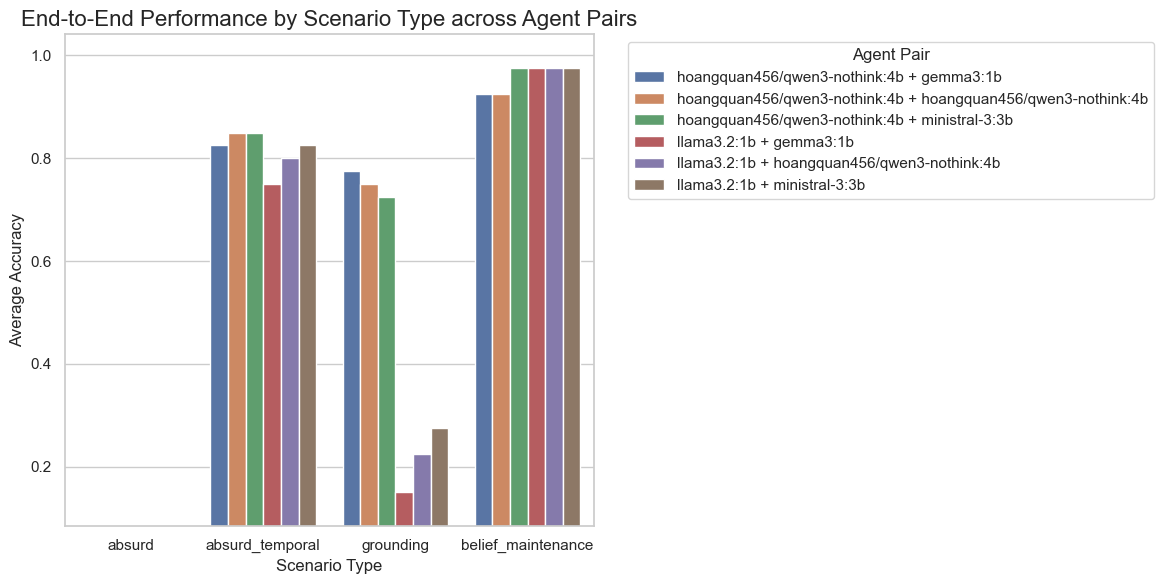

In [ ]:
# Use the same derived columns as the previous chart so this cell can run standalone.
def extract_base_domain(domain):
    for base in ['loan', 'alien_clinic', 'crime_scene', 'thorncrester']:
        if str(domain).startswith(base):
            return base
    return 'other'

def extract_scenario(domain):
    for scenario in ['_belief_maintenance', '_negation', '_absurd_temporal', '_grounding', '_absurd', '_trace_selection']:
        if str(domain).endswith(scenario):
            return scenario.lstrip('_')
    return 'base'

df_melted['Base_Domain'] = df_melted['Domain'].apply(extract_base_domain)
df_melted['Scenario'] = df_melted['Domain'].apply(extract_scenario)

df_e2e = df_melted[df_melted['Metric_Family'] == 'End_to_End'].copy()

scenario_order = ['absurd', 'absurd_temporal', 'grounding', 'belief_maintenance']
df_e2e = df_e2e[df_e2e['Scenario'].isin(scenario_order)].copy()
df_e2e['Scenario'] = pd.Categorical(df_e2e['Scenario'], categories=scenario_order, ordered=True)

df_plot = (
    df_e2e.groupby(['Scenario', 'Agent_Pair'], as_index=False)['Accuracy']
    .mean()
 )
all_pairs = sorted(df_plot['Agent_Pair'].unique())
scaffold = pd.MultiIndex.from_product([scenario_order, all_pairs], names=['Scenario', 'Agent_Pair']).to_frame(index=False)
df_plot = scaffold.merge(df_plot, on=['Scenario', 'Agent_Pair'], how='left')
df_plot['Accuracy'] = df_plot['Accuracy'].fillna(0.0)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='Scenario',
    y='Accuracy',
    hue='Agent_Pair',
    order=scenario_order,
    errorbar=None,
 )
plt.title('End-to-End Performance by Scenario Type across Agent Pairs', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Scenario Type')
plt.legend(title='Agent Pair', bbox_to_anchor=(1.05, 1), loc='upper left')
set_dynamic_ylim(values=df_plot['Accuracy'])
plt.tight_layout()
plt.show()


## 5. Evidence F1 by Scenario (Dual-Agent)

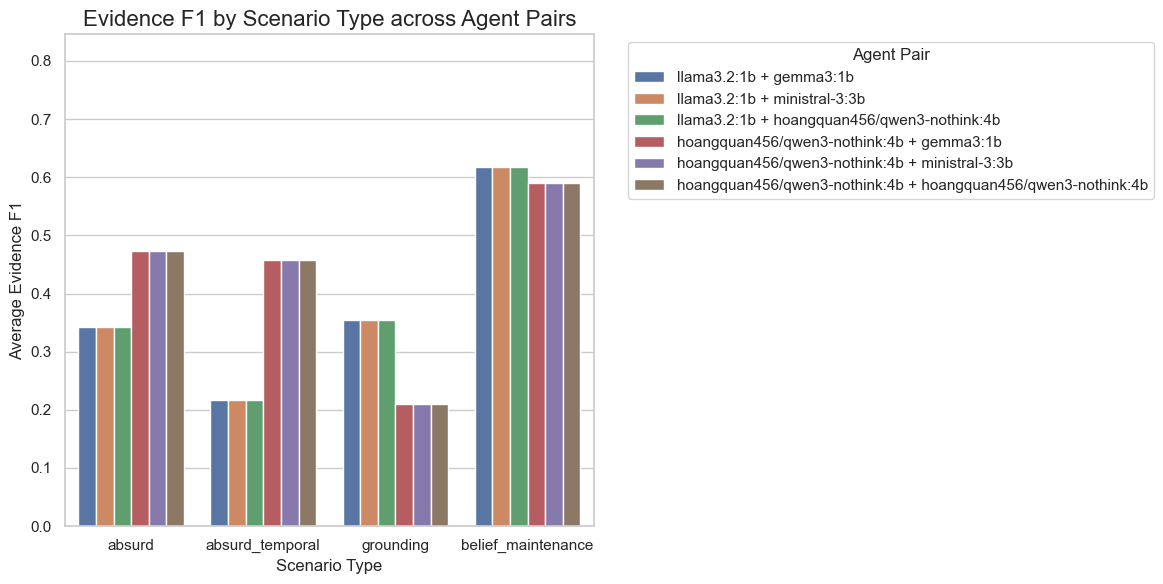

In [69]:
# Evidence F1 (dual-agent) by scenario
df_f1 = df[df['Summary_Metric'] == 'Average_Evidence_F1'].copy()

if df_f1.empty:
    print("Average_Evidence_F1 rows not found in eval_results_dual_agent.csv")
else:
    df_f1['Agent_Pair'] = df_f1['Reasoner_Model'] + " + " + df_f1['Matcher_Model']

    id_vars = ['Timestamp', 'Domain', 'Agent_Pair', 'Reasoner_Model', 'Matcher_Model', 'Temp', 'Prompt_Ver', 'Runs', 'Metric_Family']
    value_vars = ['Dual_Agent_Store', 'Dual_Agent_Store_History']

    df_f1_melted = pd.melt(
    df_f1,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Context_Type',
    value_name='F1',
    )

    df_f1_melted['F1'] = df_f1_melted['F1'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    df_f1_melted['F1'] = pd.to_numeric(df_f1_melted['F1'], errors='coerce')
    df_f1_melted = df_f1_melted.dropna(subset=['F1'])

    def extract_scenario(domain):
        for scenario in ['_belief_maintenance', '_negation', '_absurd_temporal', '_grounding', '_absurd', '_trace_selection']:
            if str(domain).endswith(scenario):
                return scenario.lstrip('_')
        return 'base'

    if 'Scenario' not in df_f1_melted.columns:
        df_f1_melted['Scenario'] = df_f1_melted['Domain'].apply(extract_scenario)

    scenario_order = ['absurd', 'absurd_temporal', 'grounding', 'belief_maintenance']
    df_f1_melted = df_f1_melted[df_f1_melted['Scenario'].isin(scenario_order)].copy()
    df_f1_melted['Scenario'] = pd.Categorical(
    df_f1_melted['Scenario'],
    categories=scenario_order,
    ordered=True,
    )

    if df_f1_melted.empty:
        print("No Evidence F1 rows match the selected scenarios.")
    else:
        plt.figure(figsize=(12, 6))
        sns.barplot(
        data=df_f1_melted,
        x='Scenario',
        y='F1',
        hue='Agent_Pair',
        order=scenario_order,
        errorbar=None,
        )
        plt.title('Evidence F1 by Scenario Type across Agent Pairs', fontsize=16)
        plt.ylabel('Average Evidence F1')
        plt.xlabel('Scenario Type')
        plt.legend(title='Agent Pair', bbox_to_anchor=(1.05, 1), loc='upper left')
        set_dynamic_ylim(values=df_f1_melted['F1'])
        plt.tight_layout()
        plt.show()


## Audit & Coverage
Sanity checks for variance consistency, coverage, and missing domains.

In [70]:
# ── Variance vs StdDev consistency (dual-agent) ──────────────────────
df_var = df[df['Summary_Metric'] == 'Variance_Raw_Score'].copy()
df_std = df[df['Summary_Metric'] == 'StdDev_Raw_Score'].copy()

if df_var.empty or df_std.empty:
    print("Variance/StdDev rows not found in eval_results_dual_agent.csv")
else:
    for col in ['Dual_Agent_Store', 'Dual_Agent_Store_History']:
        df_var[col] = df_var[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
        df_var[col] = pd.to_numeric(df_var[col], errors='coerce')
        df_std[col] = df_std[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
        df_std[col] = pd.to_numeric(df_std[col], errors='coerce')

    key_cols = ['Model', 'Domain', 'Reasoner_Model', 'Matcher_Model', 'Prompt_Ver', 'Temp', 'Runs', 'Metric_Family']
    df_var_keyed = df_var[key_cols + ['Dual_Agent_Store', 'Dual_Agent_Store_History']].copy()
    df_std_keyed = df_std[key_cols + ['Dual_Agent_Store', 'Dual_Agent_Store_History']].copy()

    merged = df_var_keyed.merge(df_std_keyed, on=key_cols, suffixes=('_var', '_std'), how='inner')

    for ctx in ['Dual_Agent_Store', 'Dual_Agent_Store_History']:
        merged[f'{ctx}_std_sq'] = merged[f'{ctx}_std'] ** 2
        merged[f'{ctx}_abs_diff'] = (merged[f'{ctx}_var'] - merged[f'{ctx}_std_sq']).abs()

    tolerance = 1e-4
    diff_cols = [f'{ctx}_abs_diff' for ctx in ['Dual_Agent_Store', 'Dual_Agent_Store_History']]
    merged['Max_Abs_Diff'] = merged[diff_cols].max(axis=1)

    flagged = merged[merged['Max_Abs_Diff'] > tolerance]
    print(f"Variance vs StdDev^2 check: {len(flagged)} rows exceed tolerance {tolerance}")
    display(flagged[key_cols + ['Max_Abs_Diff']].head(20))

# ── Coverage and missing evaluations ────────────────────────────────
known_suffixes = [
    '_belief_maintenance', '_negation', '_absurd_temporal', '_grounding',
    '_hard', '_extended', '_belief_awareness', '_absurd', '_trace_selection', '_1hop', '_2hop', '_3hop', '_4hop'
]

def detect_suffix(domain):
    for suffix in sorted(known_suffixes, key=len, reverse=True):
        if domain.endswith(suffix):
            return suffix.lstrip('_')
    return 'base'

df_acc['Detected_Suffix'] = df_acc['Domain'].apply(detect_suffix)
df_acc['Base_Domain'] = df_acc['Domain'].apply(extract_base_domain)
coverage = df_acc.groupby(['Detected_Suffix', 'Base_Domain']).size().reset_index(name='Count')
print("Scenario coverage by suffix and base domain:")
display(coverage.sort_values(['Detected_Suffix', 'Base_Domain']))

try:
    from evaluation.run_evals import DOMAIN_REGISTRY
    expected_domains = sorted(DOMAIN_REGISTRY.keys())
    observed_domains = sorted(df_acc['Domain'].unique())
    missing = sorted(set(expected_domains) - set(observed_domains))
    extra = sorted(set(observed_domains) - set(expected_domains))

    print(f"Expected domains from registry: {len(expected_domains)}")
    print(f"Observed domains in CSV: {len(observed_domains)}")
    print(f"Missing domains (in registry but not in CSV): {len(missing)}")
    display(pd.DataFrame(missing, columns=['Missing_Domain']).head(50))

    if extra:
        print(f"Extra domains (in CSV but not in registry): {len(extra)}")
        display(pd.DataFrame(extra, columns=['Extra_Domain']).head(50))
except Exception as e:
    print("Could not import DOMAIN_REGISTRY for missing-eval check:", e)


Variance/StdDev rows not found in eval_results_dual_agent.csv
Scenario coverage by suffix and base domain:


,Detected_Suffix,Base_Domain,Count
0,2hop,alien_clinic,24
1,2hop,crime_scene,24
2,2hop,loan,24
3,2hop,thorncrester,24
4,3hop,alien_clinic,24
5,3hop,crime_scene,24
6,3hop,loan,24
7,3hop,thorncrester,24
8,absurd,alien_clinic,24
9,absurd,crime_scene,24


Expected domains from registry: 54
Observed domains in CSV: 25
Missing domains (in registry but not in CSV): 29


,Missing_Domain
0,alien_clinic
1,alien_clinic_1hop
2,alien_clinic_4hop
3,alien_clinic_belief_awareness
4,alien_clinic_cf
5,alien_clinic_extended
6,alien_clinic_hard
7,alien_clinic_negation
8,crime_scene
9,crime_scene_1hop


## Extra Graphs
Additional visuals for agent pairing stability and domain sensitivity.

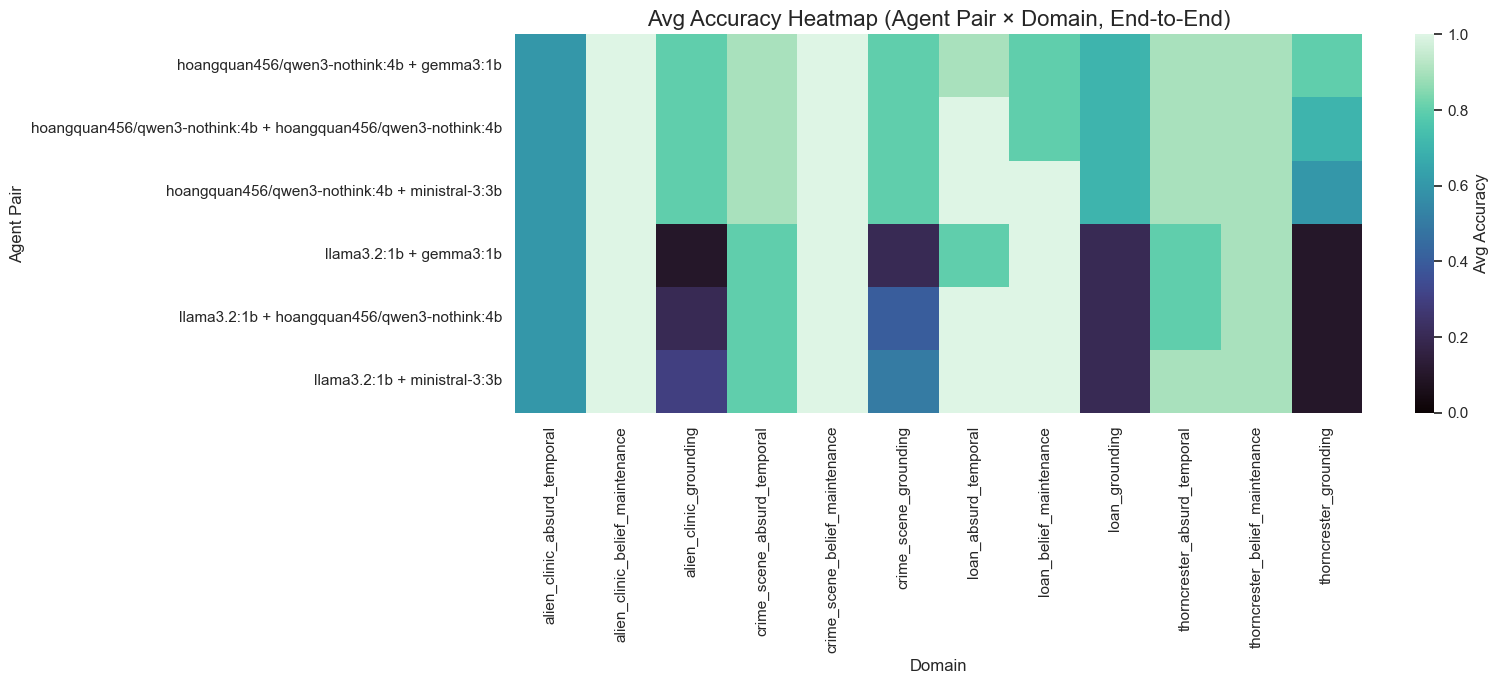

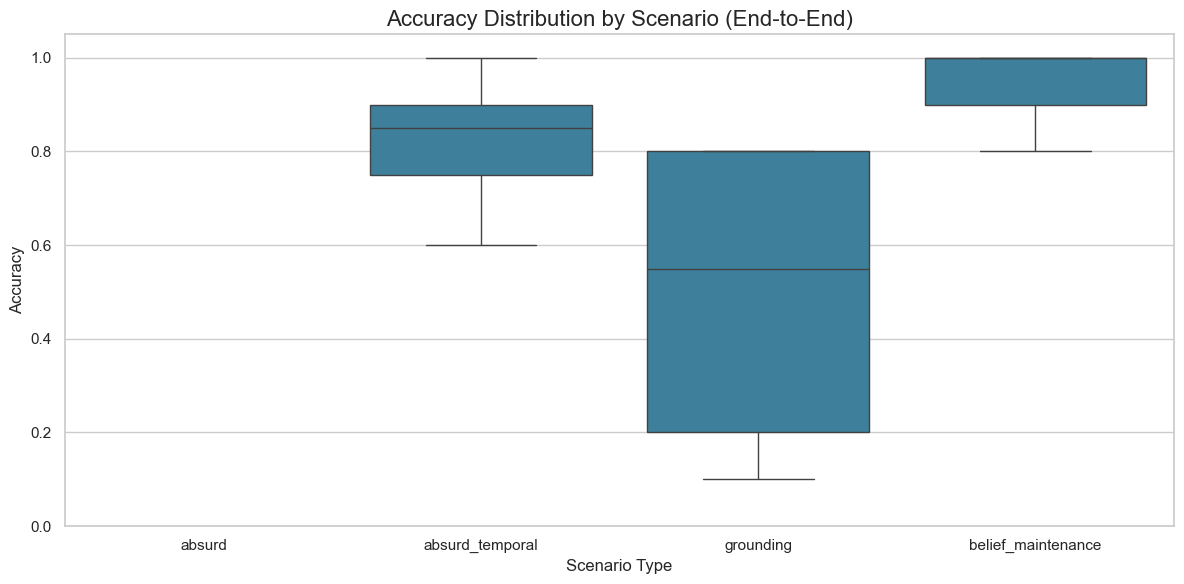

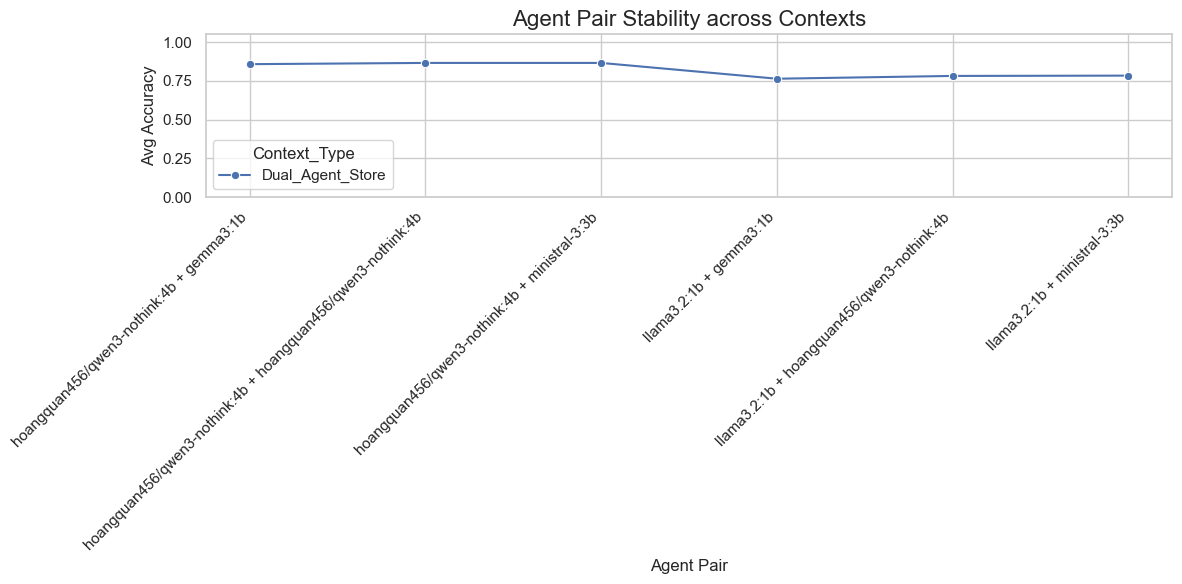

In [71]:
# ── Graph A: Heatmap of Avg Accuracy (Agent Pair × Domain, E2E) ───────
heat = (
    df_e2e.assign(Avg_Accuracy=df_e2e['Accuracy'])
    .groupby(['Agent_Pair', 'Domain'])['Avg_Accuracy']
    .mean()
    .reset_index()
    .pivot(index='Agent_Pair', columns='Domain', values='Avg_Accuracy')
 )
plt.figure(figsize=(16, 7))
sns.heatmap(heat, cmap='mako', vmin=0, vmax=1, annot=False, cbar_kws={'label': 'Avg Accuracy'})
plt.title('Avg Accuracy Heatmap (Agent Pair × Domain, End-to-End)', fontsize=16)
plt.ylabel('Agent Pair')
plt.xlabel('Domain')
plt.tight_layout()
plt.show()

# ── Graph B: Accuracy Distribution by Scenario (E2E only) ─────────────
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_e2e, x='Scenario', y='Accuracy', color='#2E86AB')
plt.title('Accuracy Distribution by Scenario (End-to-End)', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Scenario Type')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ── Graph C: Agent Pair Stability (Store vs Store+History) ────────────
pair_ctx = (
    df_melted.groupby(['Agent_Pair', 'Context_Type'])['Accuracy']
    .mean()
    .reset_index()
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=pair_ctx, x='Agent_Pair', y='Accuracy', hue='Context_Type', marker='o')
plt.title('Agent Pair Stability across Contexts', fontsize=16)
plt.ylabel('Avg Accuracy')
plt.xlabel('Agent Pair')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
